# Full EDA Notebook (Video Virality Predictor)

This notebook replaces the script-style EDA flow with an interactive, inline workflow.

- No shell wrapper required
- Plots render inline by default
- CSV/JSON export is optional


In [27]:
# Run this cell once per new environment
%pip install -q numpy pandas matplotlib

print("Dependencies installed. Re-run the next import cell.")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Dependencies installed. Re-run the next import cell.


In [28]:
import json
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    PLOT_AVAILABLE = True
except Exception as e:
    PLOT_AVAILABLE = False
    print(f"matplotlib unavailable: {e}")

try:
    from IPython.display import Markdown, display
except Exception:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text

    print("IPython.display unavailable; using plain-print fallback")


In [29]:
# Config
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "Data").exists() and (REPO_ROOT.parent / "Data").exists():
    REPO_ROOT = REPO_ROOT.parent

METADATA_CSV = REPO_ROOT / "Data" / "raw" / "Metadata" / "shorts_metadata_horizon.csv"
CLUSTER_CSV = REPO_ROOT / "Unsup_Cluster" / "cluster_results.csv"
INTERPRETATION_CSV = REPO_ROOT / "Interpretation" / "interpretation.csv"
FUSION_STATE_DBS = [
    REPO_ROOT / "state" / "fusion_concat.sqlite",
    REPO_ROOT / "state" / "fusion_sum_pool.sqlite",
    REPO_ROOT / "state" / "fusion_max_pool.sqlite",
]
FUSION_SUCCESS_STATUSES = {"success_full", "success_text_placeholder"}
TOP_N_CATEGORIES = 20

# Correlation heatmap controls (increase rows/cols by increasing CORR_MAX_FEATURES)
CORR_MAX_FEATURES = 24
CORR_MIN_NON_NULL_FRAC = 0.60

# Optional export switch (set True when you want csv/json outputs)
EXPORT_ARTIFACTS = False
EXPORT_DIR = REPO_ROOT / "EDA" / "output_notebook"

print("repo:", REPO_ROOT)
print("metadata:", METADATA_CSV)
print("cluster_csv exists:", CLUSTER_CSV.exists())
print("interpretation_csv exists:", INTERPRETATION_CSV.exists())
print("fusion_state dbs:", [str(p) for p in FUSION_STATE_DBS if p.exists()])


repo: /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor
metadata: /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/Data/raw/Metadata/shorts_metadata_horizon.csv
cluster_csv exists: True
interpretation_csv exists: True
fusion_state dbs: ['/Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/state/fusion_concat.sqlite', '/Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/state/fusion_sum_pool.sqlite', '/Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/state/fusion_max_pool.sqlite']


In [30]:
LOW_CARD_CATEGORICAL_CANDIDATES = ["channel_country", "default_language", "default_audio_language", "query"]
HIGH_CARD_EXCLUDE = {"channel_id", "channel_title"}
LEAKAGE_COLUMNS = {
    "horizon_view_count",
    "horizon_days",
    "horizon_label_type",
    "view_count",
    "like_count",
    "comment_count",
    "views_per_day",
    "likes_per_day",
    "comments_per_day",
    "likes_per_view",
    "comments_per_view",
    "views_per_hour",
    "age_days",
    "virality_score",
}

NUMERIC_CANDIDATES = [
    "channel_description_length",
    "channel_subscriber_count",
    "channel_video_count",
    "channel_view_count",
    "channel_age_days",
    "title_length",
    "description_length",
    "emoji_count",
    "hashtag_count",
    "duration_seconds",
    "thumb_width",
    "thumb_height",
    "thumb_aspect_ratio",
    "published_hour",
    "published_dayofweek",
    "target_log",
    "target_raw",
    "horizon_view_count",
    "horizon_days",
]

CATEGORICAL_CANDIDATES = [
    "query",
    "channel_country",
    "default_language",
    "default_audio_language",
    "horizon_label_type",
]

BOOLEANISH_CANDIDATES = [
    "channel_hidden_subscriber_count",
    "has_hashtags",
    "has_shorts_hashtag",
    "has_clickbait_words",
    "caption_available",
    "licensed_content",
    "is_vertical_thumb",
    "shorts_by_duration",
    "shorts_by_hashtag",
    "is_short",
    "embeddable",
    "madeForKids",
    "publicStatsViewable",
    "likes_hidden",
    "comments_disabled",
    "stats_hidden",
    "too_new_for_rates",
]


def safe_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def safe_datetime(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce", utc=True)


def normalize_boolish(series: pd.Series) -> pd.Series:
    mapping = {
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0,
        "1.0": 1,
        "0.0": 0,
        "yes": 1,
        "no": 0,
    }
    return series.astype(str).str.strip().str.lower().map(mapping)


def latest_by_video_id(df: pd.DataFrame) -> pd.DataFrame:
    if "video_id" not in df.columns:
        return df.copy()
    out = df.copy()
    cap = safe_datetime(out["captured_at"]) if "captured_at" in out.columns else pd.Series(pd.NaT, index=out.index)
    out["_captured_at_parsed"] = cap
    out = out.sort_values(["video_id", "_captured_at_parsed"], na_position="last")
    out = out.drop_duplicates(subset=["video_id"], keep="last")
    return out.drop(columns=["_captured_at_parsed"], errors="ignore")


def to_numeric_bool(series: pd.Series) -> pd.Series:
    return series.map(
        lambda x: 1
        if str(x).strip().lower() in {"1", "true", "t", "yes", "y"}
        else (0 if str(x).strip().lower() in {"0", "false", "f", "no", "n"} else np.nan)
    )


def build_metadata_frame_like_training(meta_df: pd.DataFrame, horizon_days: int) -> pd.DataFrame:
    df = meta_df.copy()
    df = df[df["horizon_days"] == int(horizon_days)].copy()

    if "captured_at" in df.columns:
        df["_captured_at_dt"] = safe_datetime(df["captured_at"])
        df = df.sort_values("_captured_at_dt")
    df = df.drop_duplicates(subset=["video_id"], keep="last")

    if "published_at" in df.columns:
        published = safe_datetime(df["published_at"])
        df["published_hour"] = published.dt.hour.astype("Float64")
        df["published_dayofweek"] = published.dt.dayofweek.astype("Float64")

    for col in ["has_hashtags", "has_shorts_hashtag", "has_clickbait_words", "caption_available", "is_vertical_thumb"]:
        if col in df.columns:
            df[col] = to_numeric_bool(df[col])

    y_raw = safe_numeric(df["horizon_view_count"]).fillna(0).clip(lower=0)
    df["target_log"] = np.log1p(y_raw)
    df["target_raw"] = y_raw.astype(float)

    for col in LEAKAGE_COLUMNS:
        if col in df.columns:
            df[f"_forbidden_{col}"] = df[col]

    return df


def get_feature_columns_like_training(df: pd.DataFrame):
    protected_cols = {
        "video_id",
        "target_log",
        "target_raw",
        "captured_at",
        "published_at",
        "_captured_at_dt",
        "horizon_days",
        "horizon_label_type",
        "horizon_view_count",
    }
    protected_cols.update({f"_forbidden_{c}" for c in LEAKAGE_COLUMNS})

    candidate_cols = [
        c
        for c in df.columns
        if c not in protected_cols and not c.startswith("_forbidden_") and c not in LEAKAGE_COLUMNS
    ]

    dropped_cols = sorted([c for c in candidate_cols if c in HIGH_CARD_EXCLUDE])
    candidate_cols = [c for c in candidate_cols if c not in HIGH_CARD_EXCLUDE]

    categorical_cols = [c for c in LOW_CARD_CATEGORICAL_CANDIDATES if c in candidate_cols]

    numeric_cols = []
    passthrough_cols = []
    for c in candidate_cols:
        if c in categorical_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            numeric_cols.append(c)
        else:
            passthrough_cols.append(c)

    dropped_cols.extend(passthrough_cols)
    dropped_cols = sorted(set(dropped_cols))
    return numeric_cols, categorical_cols, dropped_cols


def build_training_aligned_eda_frame(meta_df: pd.DataFrame):
    if "horizon_days" not in meta_df.columns or "horizon_view_count" not in meta_df.columns:
        return meta_df.copy(), pd.DataFrame(columns=["horizon_days", "rows", "rows_after_dedupe", "selected_feature_cols", "dropped_feature_cols", "dropped_feature_names"])

    horizons = sorted(meta_df["horizon_days"].dropna().unique().tolist())
    frames = []
    rows = []
    all_dropped = set()

    for horizon in horizons:
        h_raw = meta_df[meta_df["horizon_days"] == horizon].copy()
        h_df = build_metadata_frame_like_training(meta_df, int(horizon))
        numeric_cols, categorical_cols, dropped_cols = get_feature_columns_like_training(h_df)

        keep_cols = [
            "video_id",
            "captured_at",
            "published_at",
            "horizon_days",
            "horizon_label_type",
            "horizon_view_count",
            "target_log",
            "target_raw",
        ] + numeric_cols + categorical_cols
        keep_cols = [c for c in keep_cols if c in h_df.columns]

        frames.append(h_df[keep_cols].copy())
        all_dropped.update(dropped_cols)

        rows.append(
            {
                "horizon_days": horizon,
                "rows": int(len(h_raw)),
                "rows_after_dedupe": int(len(h_df)),
                "selected_feature_cols": int(len(numeric_cols) + len(categorical_cols)),
                "dropped_feature_cols": int(len(dropped_cols)),
                "dropped_feature_names": " | ".join(dropped_cols),
            }
        )

    out = pd.concat(frames, ignore_index=True, sort=False) if frames else meta_df.copy()
    summary = pd.DataFrame(rows).sort_values("horizon_days") if rows else pd.DataFrame(columns=["horizon_days", "rows", "rows_after_dedupe", "selected_feature_cols", "dropped_feature_cols", "dropped_feature_names"])
    return out, summary


def load_fusion_state_tables(sqlite_paths):
    out = {}
    for p in sqlite_paths:
        p = Path(p)
        if not p.exists():
            continue
        strategy = p.stem.replace("fusion_", "")
        try:
            with sqlite3.connect(str(p)) as conn:
                frame = pd.read_sql_query("SELECT video_id, status FROM processed_items", conn)
            frame["video_id"] = frame["video_id"].astype(str)
            frame["status"] = frame["status"].astype(str)
            out[strategy] = frame
        except Exception as e:
            print(f"skip {p}: {e}")
    return out


In [31]:
# Load metadata and align to training feature-set logic.
if not METADATA_CSV.exists():
    raise FileNotFoundError(f"Metadata CSV not found: {METADATA_CSV}")

raw_df = pd.read_csv(METADATA_CSV, low_memory=False)
df, training_column_drop_summary = build_training_aligned_eda_frame(raw_df)
latest = latest_by_video_id(df)

overview = {
    "metadata_csv": str(METADATA_CSV),
    "raw_rows": int(len(raw_df)),
    "raw_columns": int(len(raw_df.columns)),
    "training_aligned_rows": int(len(df)),
    "training_aligned_columns": int(len(df.columns)),
    "raw_unique_video_id": int(raw_df["video_id"].astype(str).nunique()) if "video_id" in raw_df.columns else 0,
    "raw_duplicate_video_id_rows": int(len(raw_df) - raw_df["video_id"].astype(str).nunique()) if "video_id" in raw_df.columns else 0,
    "rows_latest_per_video": int(len(latest)),
    "horizon_days_distribution_aligned": df["horizon_days"].value_counts(dropna=False).to_dict() if "horizon_days" in df.columns else {},
}

display(Markdown("## Dataset Snapshot (Training-Aligned EDA)"))
display(pd.DataFrame([overview]))

display(Markdown("## Columns Dropped To Match Training"))
display(training_column_drop_summary)


## Dataset Snapshot (Training-Aligned EDA)

,metadata_csv,raw_rows,raw_columns,training_aligned_rows,training_aligned_columns,raw_unique_video_id,raw_duplicate_video_id_rows,rows_latest_per_video,horizon_days_distribution_aligned
0,/Users/wkdghdus/Desktop/coding/clipfarm/video-...,20073,70,20072,33,20031,42,20031,"{7: 10551, 30: 9521}"


## Columns Dropped To Match Training

,horizon_days,rows,rows_after_dedupe,selected_feature_cols,dropped_feature_cols,dropped_feature_names
0,7,10551,10551,25,30,category_type | channel_created_at | channel_c...
1,30,9522,9521,25,30,category_type | channel_created_at | channel_c...


In [32]:
# Missingness
missing_df = (
    pd.DataFrame({
        "column": df.columns,
        "missing_count": [int(df[c].isna().sum()) for c in df.columns],
        "missing_pct": [float(df[c].isna().mean() * 100.0) for c in df.columns],
    })
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("## Missingness (Top 20)"))
display(missing_df.head(20))


## Missingness (Top 20)

,column,missing_count,missing_pct
0,channel_median_shorts_view_count,20072,100.000000
1,channel_country,6668,33.220407
2,channel_age_days,2057,10.248107
3,has_hashtags,2055,10.238143
4,title_length,2055,10.238143
5,caption_available,2055,10.238143
6,duration_seconds,2055,10.238143
7,hashtag_count,2055,10.238143
8,has_clickbait_words,2055,10.238143
9,has_shorts_hashtag,2055,10.238143


In [33]:
# Numeric summary + correlations
numeric_data = {}
for col in NUMERIC_CANDIDATES:
    if col in df.columns:
        numeric_data[col] = safe_numeric(df[col])
for col in BOOLEANISH_CANDIDATES:
    if col in df.columns:
        numeric_data[col] = normalize_boolish(df[col])

numeric_df = pd.DataFrame(numeric_data)
if numeric_df.shape[1] > 0:
    numeric_summary = numeric_df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).transpose().reset_index().rename(columns={"index": "column"})
else:
    numeric_summary = pd.DataFrame(columns=["column"])

# Build a larger, training-aligned correlation matrix.
# Keep columns with enough non-null values and non-trivial variation.
corr_candidates = []
if not numeric_df.empty:
    for c in numeric_df.columns:
        s = safe_numeric(numeric_df[c])
        non_null_frac = float(s.notna().mean())
        uniq = int(s.nunique(dropna=True))
        std = float(s.std(skipna=True)) if s.notna().any() else 0.0
        if non_null_frac < CORR_MIN_NON_NULL_FRAC:
            continue
        if uniq < 2:
            continue
        corr_candidates.append((c, int(s.notna().sum()), abs(std)))

corr_candidates = sorted(corr_candidates, key=lambda x: (-x[1], -x[2], x[0]))
corr_cols = [c for c, _n, _std in corr_candidates[:CORR_MAX_FEATURES]]
corr_df = numeric_df[corr_cols].corr() if len(corr_cols) >= 2 else pd.DataFrame()

horizon_summary = pd.DataFrame()
if "horizon_days" in df.columns:
    rows = []
    for horizon, grp in df.groupby("horizon_days", dropna=False):
        row = {
            "horizon_days": horizon,
            "rows": int(len(grp)),
            "unique_videos": int(grp["video_id"].astype(str).nunique()) if "video_id" in grp.columns else None,
        }
        for col in ["horizon_view_count", "virality_score", "view_count", "likes_per_view", "comments_per_view"]:
            row[f"mean_{col}"] = float(safe_numeric(grp[col]).mean()) if col in grp.columns else None
        rows.append(row)
    horizon_summary = pd.DataFrame(rows).sort_values("horizon_days")

display(Markdown("## Numeric Summary"))
display(numeric_summary.head(30))
display(Markdown("## Horizon Summary"))
display(horizon_summary)
display(Markdown(f"## Correlations (features used: {len(corr_cols)})"))
if corr_cols:
    display(pd.DataFrame({"corr_features": corr_cols}))
display(corr_df)


## Numeric Summary

,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,channel_description_length,20072.0,294.304255,292.690696,0.0,0.0,0.0,54.0,186.0,478.0,920.0,996.0,1432.0
1,channel_subscriber_count,20070.0,1824426.420379,7666780.2987,0.0,30.0,291.0,10700.0,87400.0,674000.0,10900000.0,26400000.0,468000000.0
2,channel_video_count,20070.0,12376.098156,63407.061192,0.0,8.0,25.0,133.0,450.0,1326.0,24055.65,364964.05,708530.0
3,channel_view_count,20070.0,1512751628.77135,5692770627.430843,0.0,10275.61,149789.25,8409292.5,73105884.0,512450527.0,7902066777.4,24115447615.0,332265613162.0
4,channel_age_days,18015.0,1771.82869,1752.711501,6.507527,20.597894,49.085537,360.256166,1172.080378,2759.303946,5305.956141,7106.157361,7459.154252
5,title_length,18017.0,68.500749,24.097793,1.0,12.0,26.0,50.0,71.0,91.0,99.0,100.0,102.0
6,description_length,18017.0,405.409447,814.197925,0.0,0.0,0.0,0.0,28.0,445.0,2119.2,4357.6,5000.0
7,emoji_count,18017.0,2.199978,31.951515,0.0,0.0,0.0,0.0,1.0,2.0,8.0,18.0,4246.0
8,hashtag_count,18017.0,9.973247,24.50079,0.0,0.0,0.0,3.0,5.0,9.0,29.0,103.0,708.0
9,duration_seconds,18017.0,49.289393,43.597446,0.0,5.0,8.0,18.0,36.0,61.0,155.0,204.84,239.0


## Horizon Summary

,horizon_days,rows,unique_videos,mean_horizon_view_count,mean_virality_score,mean_view_count,mean_likes_per_view,mean_comments_per_view
0,7,10551,10551,9.800707e+05,None,None,None,None
1,30,9521,9521,2.240097e+06,None,None,None,None


## Correlations (features used: 23)

,corr_features
0,horizon_view_count
1,target_raw
2,channel_description_length
3,horizon_days
4,published_hour
5,target_log
6,published_dayofweek
7,channel_view_count
8,channel_subscriber_count
9,channel_video_count


,horizon_view_count,target_raw,channel_description_length,horizon_days,published_hour,target_log,published_dayofweek,channel_view_count,channel_subscriber_count,channel_video_count,...,emoji_count,hashtag_count,title_length,thumb_height,has_shorts_hashtag,has_hashtags,has_clickbait_words,caption_available,thumb_aspect_ratio,channel_age_days
horizon_view_count,1.000000,1.000000,0.025844,0.108160,0.007961,0.363767,-0.002963,0.203273,0.343891,-0.009396,...,-0.000094,-0.011469,-0.054114,0.015862,0.058614,-0.025378,-0.006448,0.006650,0.015837,0.002371
target_raw,1.000000,1.000000,0.025844,0.108160,0.007961,0.363767,-0.002963,0.203273,0.343891,-0.009396,...,-0.000094,-0.011469,-0.054114,0.015862,0.058614,-0.025378,-0.006448,0.006650,0.015837,0.002371
channel_description_length,0.025844,0.025844,1.000000,0.026264,0.002326,0.034272,0.006065,0.146435,0.141768,0.254223,...,0.017777,0.091401,0.099161,-0.016940,0.094570,0.034454,0.076658,0.021904,-0.016941,0.097653
horizon_days,0.108160,0.108160,0.026264,1.000000,0.092712,0.004962,0.000948,0.064177,0.061599,0.027440,...,0.007157,-0.042459,-0.080410,-0.024034,-0.040159,-0.083232,-0.005542,0.031732,-0.023590,0.097031
published_hour,0.007961,0.007961,0.002326,0.092712,1.000000,0.013617,-0.042956,0.007522,0.015829,-0.005941,...,-0.001866,-0.052200,-0.082442,0.008657,-0.023425,-0.072036,0.003258,0.010952,0.008968,0.091480
target_log,0.363767,0.363767,0.034272,0.004962,0.013617,1.000000,0.007023,0.180696,0.157896,0.065825,...,0.003009,0.000424,-0.041374,0.065535,0.103585,-0.028846,-0.017822,-0.000128,0.065668,0.068862
published_dayofweek,-0.002963,-0.002963,0.006065,0.000948,-0.042956,0.007023,1.000000,-0.008049,-0.011414,-0.006233,...,0.013015,0.007281,0.031922,0.011411,0.029090,0.029462,0.003060,-0.003544,0.010722,-0.018100
channel_view_count,0.203273,0.203273,0.146435,0.064177,0.007522,0.180696,-0.008049,1.000000,0.814943,0.488204,...,-0.006151,0.001323,0.002158,0.020462,0.051503,-0.021805,-0.035521,0.044294,0.020473,0.286208
channel_subscriber_count,0.343891,0.343891,0.141768,0.061599,0.015829,0.157896,-0.011414,0.814943,1.000000,0.410209,...,-0.005814,-0.012222,-0.009892,0.017973,0.037506,-0.042390,-0.033225,0.040295,0.017968,0.290710
channel_video_count,-0.009396,-0.009396,0.254223,0.027440,-0.005941,0.065825,-0.006233,0.488204,0.410209,1.000000,...,-0.008542,0.064812,0.083937,0.015828,-0.035997,0.024531,-0.031502,0.008182,0.015844,0.312982


In [34]:
# Categorical summary
cat_rows = []
for col in CATEGORICAL_CANDIDATES:
    if col not in df.columns:
        continue
    raw = df[col]
    vc = raw.fillna("<NA>").astype(str).value_counts(dropna=False)
    cat_rows.append({
        "column": col,
        "unique_values": int(raw.nunique(dropna=True)),
        "missing_pct": float(raw.isna().mean() * 100.0),
        "top_5": " | ".join(f"{k}:{v}" for k, v in vc.head(5).items()),
    })
categorical_summary = pd.DataFrame(cat_rows).sort_values("unique_values", ascending=False) if cat_rows else pd.DataFrame(columns=["column", "unique_values", "missing_pct", "top_5"])

display(Markdown("## Categorical Summary"))
display(categorical_summary)


## Categorical Summary

,column,unique_values,missing_pct,top_5
1,channel_country,103,33.220407,<NA>:6668 | IN:5186 | US:3318 | ID:480 | BR:417
3,default_audio_language,102,10.238143,en:5545 | hi:3972 | <NA>:2055 | en-US:1146 | i...
2,default_language,99,10.238143,en:10287 | <NA>:2055 | hi:944 | en-US:830 | en...
0,query,12,0.000000,sports:1794 | shorts:1788 | music:1768 | gamin...
4,horizon_label_type,1,0.000000,views_at_age:20072


In [35]:
# Optional joins: cluster + interpretation
cluster_join_summary = {}
cluster_summary_df = pd.DataFrame()
if CLUSTER_CSV.exists() and "video_id" in latest.columns:
    clusters = pd.read_csv(CLUSTER_CSV)
    clusters["video_id"] = clusters["video_id"].astype(str)

    merged = latest.copy()
    merged["video_id"] = merged["video_id"].astype(str)
    merged = merged.merge(clusters, on="video_id", how="left")

    coverage = float(merged["cluster"].notna().mean() * 100.0) if "cluster" in merged.columns else 0.0
    cluster_join_summary = {
        "cluster_csv": str(CLUSTER_CSV),
        "rows_in_cluster_csv": int(len(clusters)),
        "coverage_pct_on_latest_metadata": coverage,
    }

    if "cluster" in merged.columns:
        agg_spec = {"n_videos": ("video_id", "nunique")}
        if "horizon_view_count" in merged.columns:
            agg_spec["mean_horizon_view_count"] = ("horizon_view_count", "mean")
        if "target_raw" in merged.columns:
            agg_spec["mean_target_raw"] = ("target_raw", "mean")
        if "target_log" in merged.columns:
            agg_spec["mean_target_log"] = ("target_log", "mean")

        cluster_summary_df = (
            merged.groupby("cluster", dropna=True)
            .agg(**agg_spec)
            .reset_index()
            .sort_values("n_videos", ascending=False)
        )

interpretation_summary = {}
interpretation_cluster_means = pd.DataFrame()
if INTERPRETATION_CSV.exists():
    interpretation_df = pd.read_csv(INTERPRETATION_CSV)
    interpretation_summary = {
        "interpretation_csv": str(INTERPRETATION_CSV),
        "rows": int(len(interpretation_df)),
        "columns": int(len(interpretation_df.columns)),
        "video_available_pct": float(interpretation_df["video_available"].mean() * 100.0) if "video_available" in interpretation_df.columns and len(interpretation_df) else None,
        "audio_available_pct": float(interpretation_df["audio_available"].mean() * 100.0) if "audio_available" in interpretation_df.columns and len(interpretation_df) else None,
    }
    interp_cols = [c for c in ["motion_mean", "cut_rate_per_min", "audio_rms_mean", "audio_rms_std", "visual_density"] if c in interpretation_df.columns]
    if "cluster" in interpretation_df.columns and interp_cols:
        interpretation_cluster_means = interpretation_df.groupby("cluster", dropna=False)[interp_cols].mean().reset_index()

display(Markdown("## Cluster Join Coverage"))
display(pd.DataFrame([cluster_join_summary]) if cluster_join_summary else pd.DataFrame([{"note": "cluster file missing or no video_id"}]))
if not cluster_summary_df.empty:
    display(cluster_summary_df)

display(Markdown("## Interpretation Coverage"))
display(pd.DataFrame([interpretation_summary]) if interpretation_summary else pd.DataFrame([{"note": "interpretation file missing"}]))
if not interpretation_cluster_means.empty:
    display(interpretation_cluster_means)


## Cluster Join Coverage

,cluster_csv,rows_in_cluster_csv,coverage_pct_on_latest_metadata
0,/Users/wkdghdus/Desktop/coding/clipfarm/video-...,222,0.0


## Interpretation Coverage

,interpretation_csv,rows,columns,video_available_pct,audio_available_pct
0,/Users/wkdghdus/Desktop/coding/clipfarm/video-...,222,8,None,None


,cluster,motion_mean,cut_rate_per_min,audio_rms_mean,audio_rms_std,visual_density
0,0,36.068405,74.640425,0.157817,0.100100,0.096763
1,1,26.495335,49.408681,0.142950,0.080732,0.110663
2,2,32.283187,66.618035,0.134395,0.081027,0.115607
3,3,34.226977,68.216397,0.081246,0.060418,0.111654
4,4,25.217235,50.181242,0.130955,0.071825,0.102484
5,5,19.864939,35.843885,0.146996,0.074575,0.101959
6,6,33.075434,68.744626,0.153082,0.087402,0.087482
7,7,30.881974,57.584563,0.102579,0.076861,0.098201
8,8,25.679912,49.360660,0.164487,0.105185,0.128595
9,9,24.903254,46.201981,0.115680,0.092162,0.120367


In [36]:
# Training-readiness coverage from local fusion state DBs
fusion_state = load_fusion_state_tables(FUSION_STATE_DBS)

fusion_status_df = pd.DataFrame(columns=["strategy", "status", "count"])
training_funnel_df = pd.DataFrame(columns=[
    "strategy",
    "horizon_days",
    "rows_after_horizon_filter",
    "rows_after_latest_dedupe",
    "rows_after_fusion_success",
    "dropped_by_fusion_join",
    "success_rate_after_dedupe_pct",
])
horizon_fusion_status_df = pd.DataFrame(columns=["strategy", "horizon_days", "status", "count"])

source_for_funnel = raw_df if "raw_df" in globals() else df
if fusion_state and "video_id" in source_for_funnel.columns and "horizon_days" in source_for_funnel.columns:
    status_rows = []
    funnel_rows = []
    horizon_rows = []

    horizons = sorted(source_for_funnel["horizon_days"].dropna().unique().tolist())
    for strategy, state_df in fusion_state.items():
        for status, count in state_df["status"].value_counts(dropna=False).items():
            status_rows.append({"strategy": strategy, "status": str(status), "count": int(count)})

        for horizon in horizons:
            filtered = source_for_funnel[source_for_funnel["horizon_days"] == horizon].copy()
            dedup = latest_by_video_id(filtered)
            joined = dedup[["video_id"]].astype(str).merge(state_df, on="video_id", how="left")
            joined_status = joined["status"].fillna("missing_in_fusion_state")
            success_count = int(joined_status.isin(FUSION_SUCCESS_STATUSES).sum())

            funnel_rows.append({
                "strategy": strategy,
                "horizon_days": horizon,
                "rows_after_horizon_filter": int(len(filtered)),
                "rows_after_latest_dedupe": int(len(dedup)),
                "rows_after_fusion_success": success_count,
                "dropped_by_fusion_join": int(len(dedup) - success_count),
                "success_rate_after_dedupe_pct": float((success_count / len(dedup)) * 100.0) if len(dedup) else 0.0,
            })

            for status, count in joined_status.value_counts(dropna=False).items():
                horizon_rows.append({
                    "strategy": strategy,
                    "horizon_days": horizon,
                    "status": str(status),
                    "count": int(count),
                })

    fusion_status_df = pd.DataFrame(status_rows).sort_values(["strategy", "count"], ascending=[True, False])
    training_funnel_df = pd.DataFrame(funnel_rows).sort_values(["strategy", "horizon_days"]).reset_index(drop=True)
    horizon_fusion_status_df = pd.DataFrame(horizon_rows).sort_values(["strategy", "horizon_days", "count"], ascending=[True, True, False]).reset_index(drop=True)

training_coverage_summary = {
    "available": bool(not training_funnel_df.empty),
    "detected_strategies": sorted(fusion_state.keys()),
    "success_statuses": sorted(FUSION_SUCCESS_STATUSES),
    "n_fusion_state_rows_total": int(sum(len(v) for v in fusion_state.values())) if fusion_state else 0,
}

display(Markdown("## Training Readiness Coverage"))
display(pd.DataFrame([training_coverage_summary]))
display(training_funnel_df)


## Training Readiness Coverage

,available,detected_strategies,success_statuses,n_fusion_state_rows_total
0,True,"[concat, max_pool, sum_pool]","[success_full, success_text_placeholder]",60093


,strategy,horizon_days,rows_after_horizon_filter,rows_after_latest_dedupe,rows_after_fusion_success,dropped_by_fusion_join,success_rate_after_dedupe_pct
0,concat,7,10551,10551,5383,5168,51.018861
1,concat,30,9522,9521,4887,4634,51.328642
2,max_pool,7,10551,10551,5383,5168,51.018861
3,max_pool,30,9522,9521,4887,4634,51.328642
4,sum_pool,7,10551,10551,5383,5168,51.018861
5,sum_pool,30,9522,9521,4887,4634,51.328642


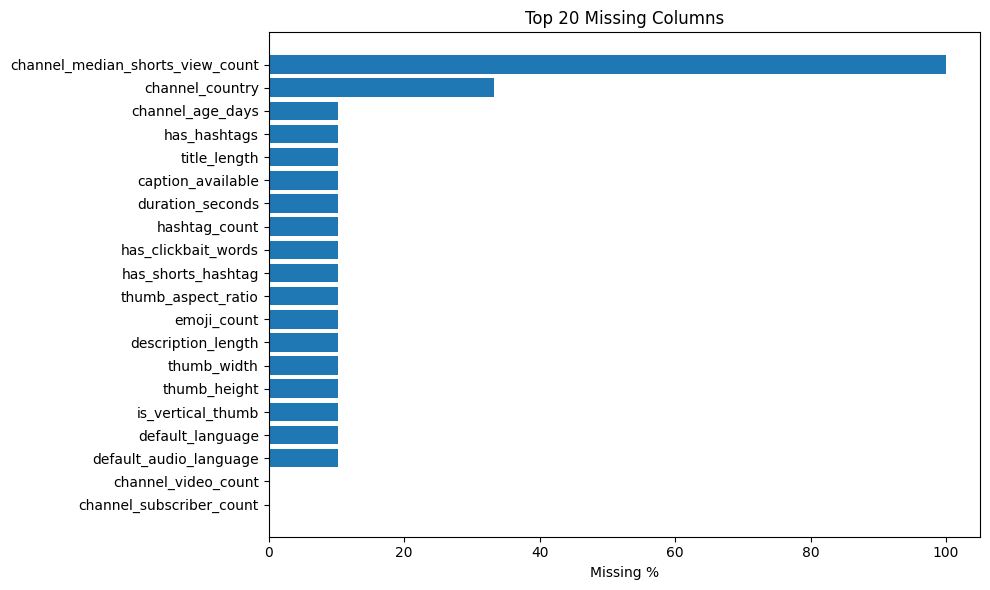

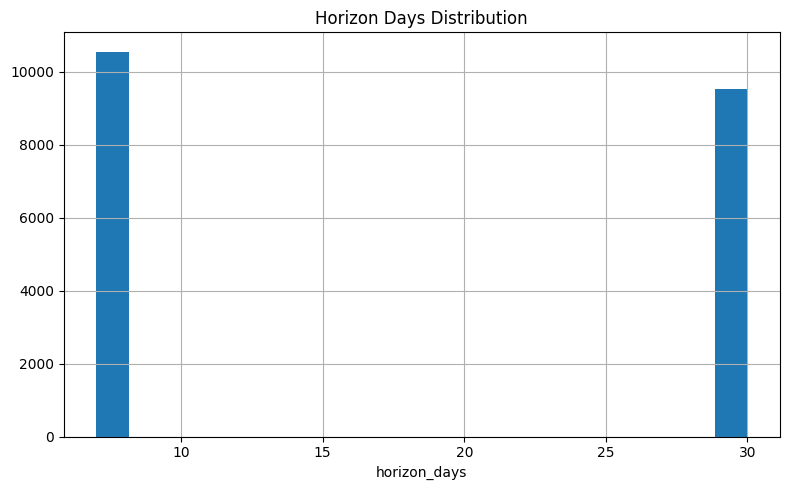

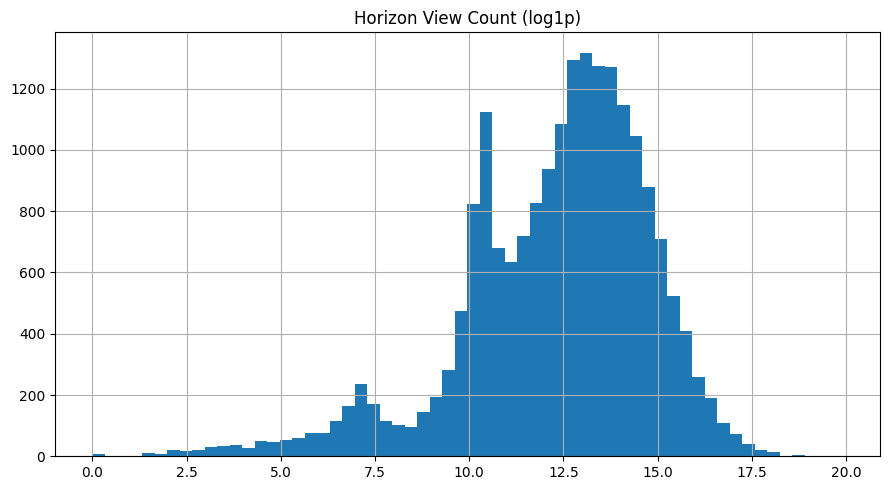

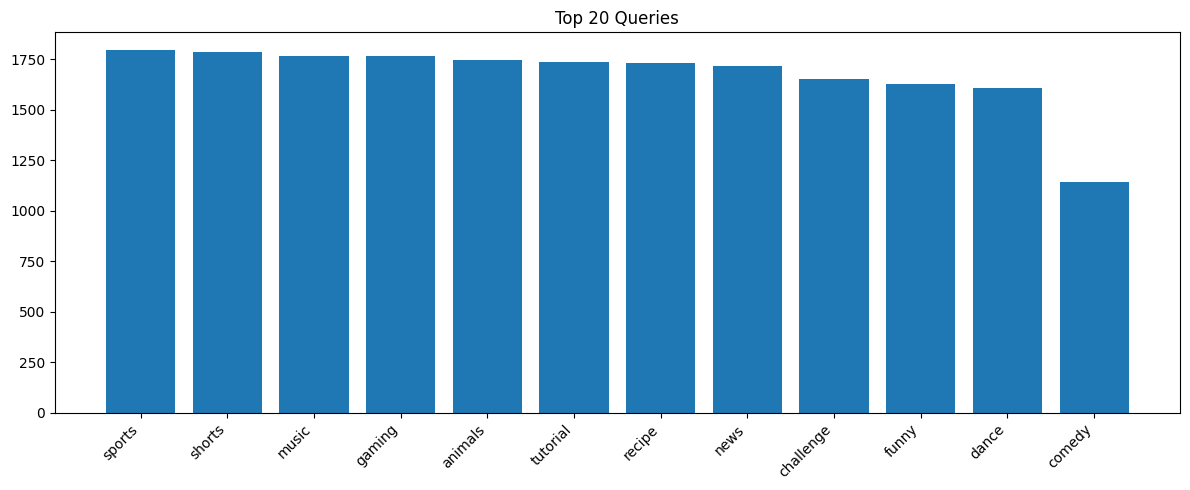

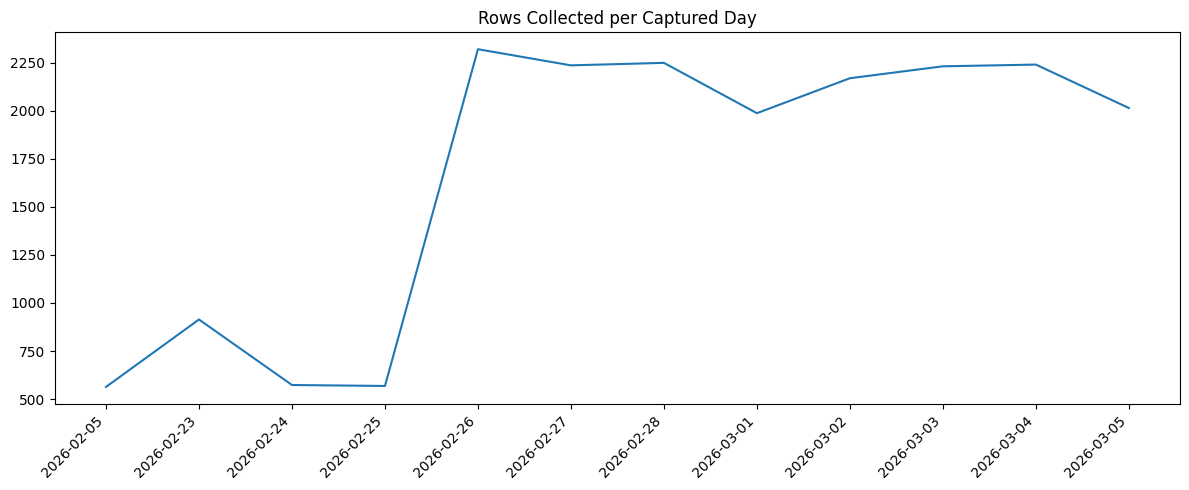

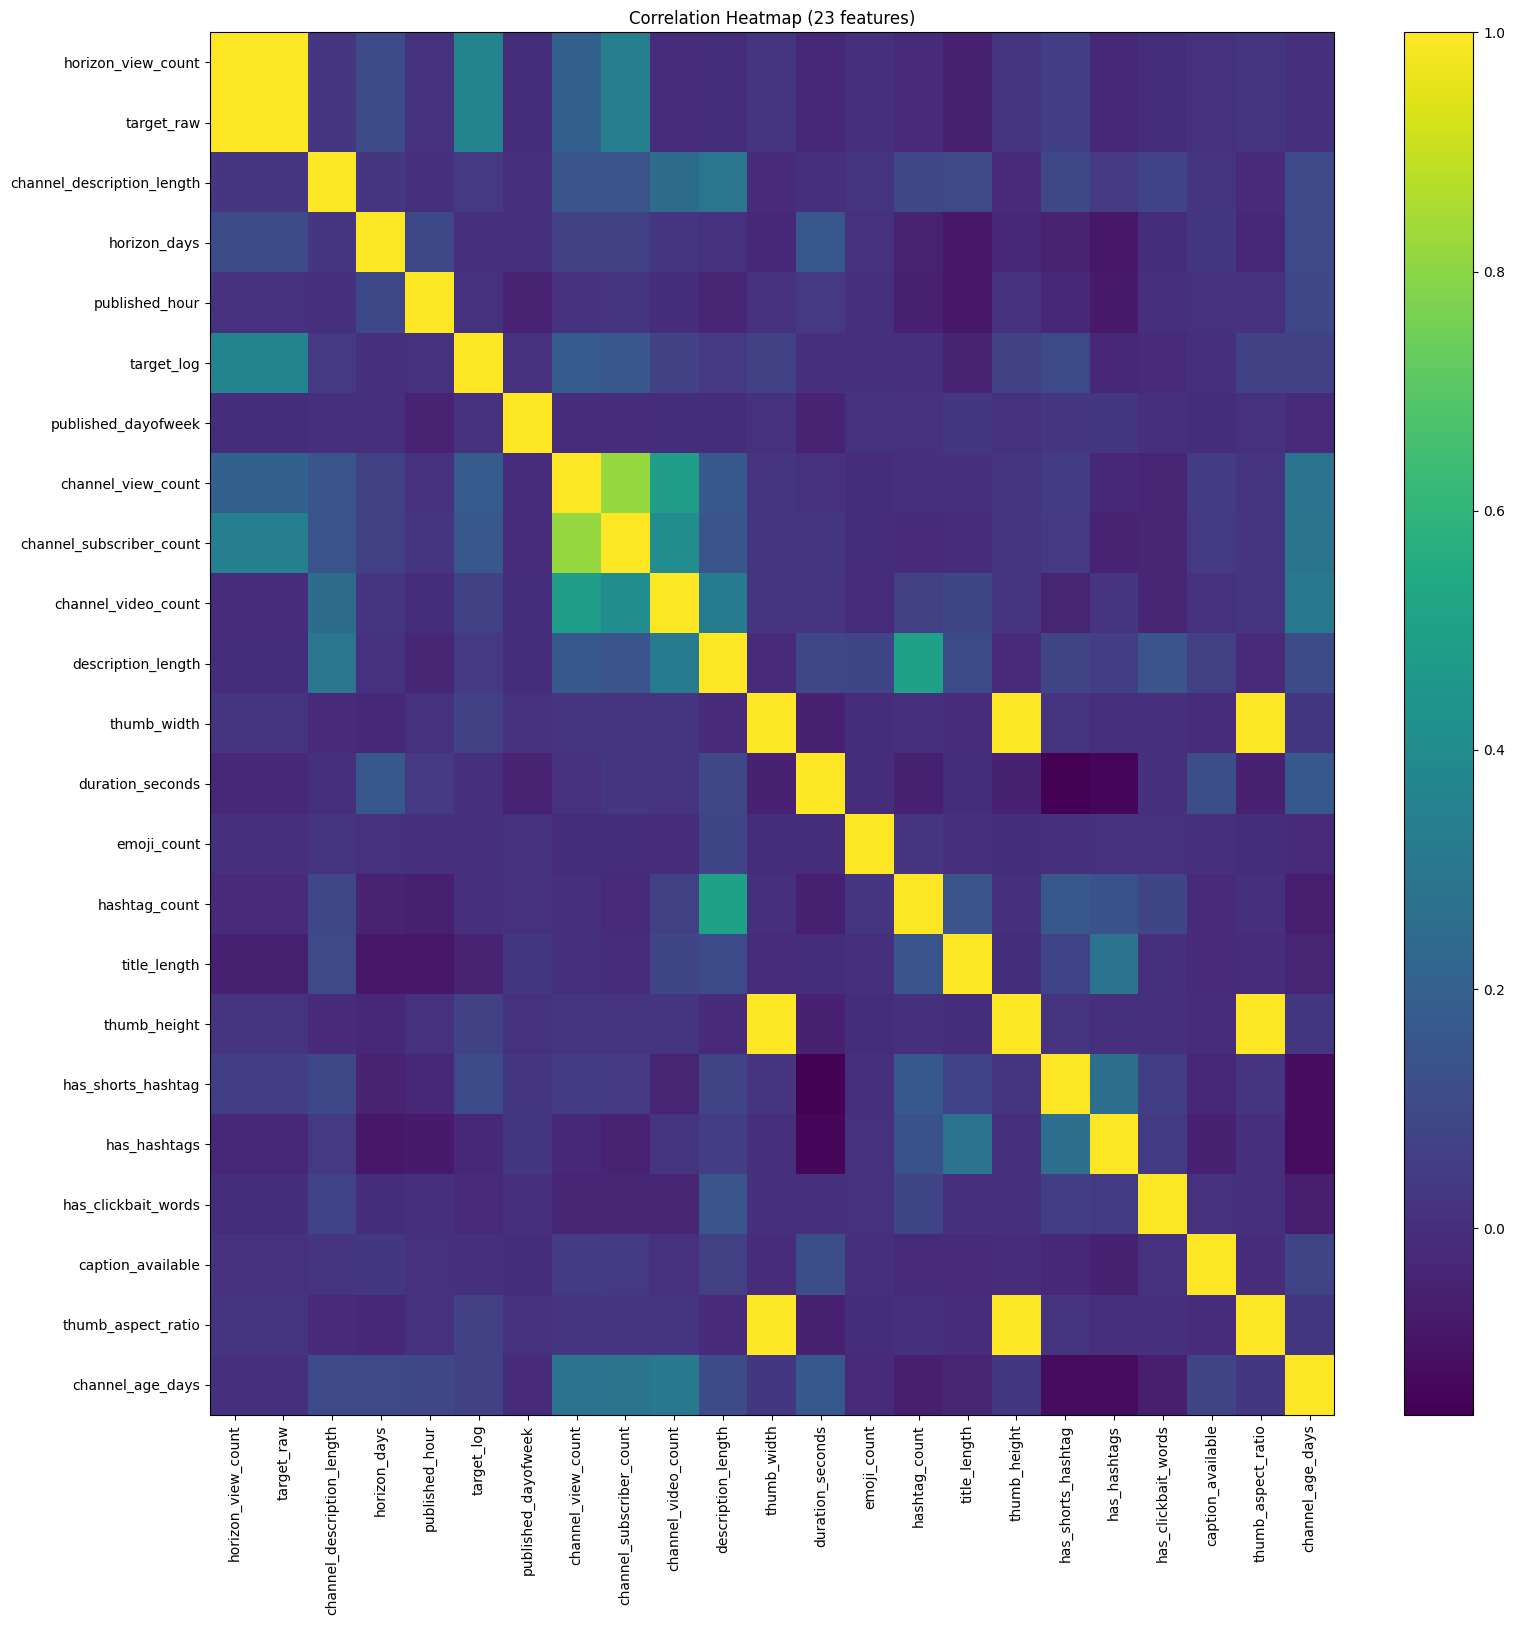

In [37]:
# Inline plots (no file output required)
if not PLOT_AVAILABLE:
    display(Markdown("Plotting skipped: matplotlib unavailable"))
else:
    fig = plt.figure(figsize=(10, 6))
    top_missing = missing_df.head(20)
    plt.barh(top_missing["column"][::-1], top_missing["missing_pct"][::-1])
    plt.title("Top 20 Missing Columns")
    plt.xlabel("Missing %")
    plt.tight_layout()
    plt.show()

    if "horizon_days" in df.columns:
        plt.figure(figsize=(8, 5))
        safe_numeric(df["horizon_days"]).dropna().hist(bins=20)
        plt.title("Horizon Days Distribution")
        plt.xlabel("horizon_days")
        plt.tight_layout()
        plt.show()

    if "horizon_view_count" in numeric_df.columns:
        plt.figure(figsize=(9, 5))
        np.log1p(numeric_df["horizon_view_count"].dropna()).hist(bins=60)
        plt.title("Horizon View Count (log1p)")
        plt.tight_layout()
        plt.show()

    if "virality_score" in numeric_df.columns:
        plt.figure(figsize=(9, 5))
        numeric_df["virality_score"].dropna().hist(bins=60)
        plt.title("Virality Score Distribution")
        plt.tight_layout()
        plt.show()

    if "query" in df.columns:
        q = df["query"].fillna("<NA>").astype(str).value_counts().head(TOP_N_CATEGORIES)
        if not q.empty:
            plt.figure(figsize=(12, 5))
            plt.bar(q.index, q.values)
            plt.xticks(rotation=45, ha="right")
            plt.title(f"Top {TOP_N_CATEGORIES} Queries")
            plt.tight_layout()
            plt.show()

    if "captured_at" in df.columns:
        d = safe_datetime(df["captured_at"]).dropna().dt.date.value_counts().sort_index()
        if not d.empty:
            plt.figure(figsize=(12, 5))
            plt.plot(d.index.astype(str), d.values)
            plt.xticks(rotation=45, ha="right")
            plt.title("Rows Collected per Captured Day")
            plt.tight_layout()
            plt.show()

    if not corr_df.empty:
        side = max(10, min(22, 6 + 0.45 * len(corr_df.columns)))
        plt.figure(figsize=(side, side))
        plt.imshow(corr_df.values, aspect="auto")
        plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
        plt.yticks(range(len(corr_df.index)), corr_df.index)
        plt.title(f"Correlation Heatmap ({len(corr_df.columns)} features)")
        plt.colorbar()
        plt.tight_layout()
        plt.show()


In [38]:
# Assemble report payload in-memory
overview_payload = {
    "overview": overview,
    "training_column_drop_summary": training_column_drop_summary.to_dict(orient="records"),
    "cluster_join_summary": cluster_join_summary,
    "interpretation_summary": interpretation_summary,
    "training_coverage_summary": training_coverage_summary,
}

tables = {
    "missingness": missing_df,
    "numeric_summary": numeric_summary,
    "categorical_summary": categorical_summary,
    "horizon_summary": horizon_summary,
    "training_column_drop_summary": training_column_drop_summary,
    "correlations": corr_df.reset_index().rename(columns={"index": "column"}) if not corr_df.empty else pd.DataFrame(columns=["column"]),
    "cluster_summary": cluster_summary_df,
    "interpretation_cluster_means": interpretation_cluster_means,
    "fusion_status_counts": fusion_status_df,
    "training_row_funnel": training_funnel_df,
    "horizon_fusion_status_counts": horizon_fusion_status_df,
}

display(Markdown("## Overview Payload"))
display(pd.DataFrame([overview_payload]))


## Overview Payload

,overview,training_column_drop_summary,cluster_join_summary,interpretation_summary,training_coverage_summary
0,{'metadata_csv': '/Users/wkdghdus/Desktop/codi...,"[{'horizon_days': 7, 'rows': 10551, 'rows_afte...",{'cluster_csv': '/Users/wkdghdus/Desktop/codin...,{'interpretation_csv': '/Users/wkdghdus/Deskto...,"{'available': True, 'detected_strategies': ['c..."


In [39]:
# Optional export (off by default)
if EXPORT_ARTIFACTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    tables_dir = EXPORT_DIR / "tables"
    tables_dir.mkdir(parents=True, exist_ok=True)

    for name, frame in tables.items():
        frame.to_csv(tables_dir / f"{name}.csv", index=False)

    (EXPORT_DIR / "overview.json").write_text(json.dumps(overview_payload, indent=2), encoding="utf-8")
    print(f"Exported EDA artifacts to: {EXPORT_DIR}")
else:
    print("EXPORT_ARTIFACTS=False -> no files written")


EXPORT_ARTIFACTS=False -> no files written
